# EP1 Deep Learning - Fashion-MNIST

## Cuaderno final de entrega y defensa

Este cuaderno integra datos, preprocesamiento, arquitectura MLP, entrenamiento, una comparación de hiperparámetros, métricas, decisiones y evidencia final. Usa exclusivamente la implementación canónica del repositorio.

## Contrato de evaluación

Las celdas ejecutables trabajan solamente con train y validation. La demostración entrena modelos nuevos para explicar el pipeline y no cambia ninguna decisión experimental. F1 ya fue evaluado una vez sobre test y se presenta al final como registro congelado: este cuaderno no entrena F1 ni realiza predicciones sobre test.

In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

URL = 'https://github.com/LucasMoncadaCL/ep1-deep-learning-fashion-mnist.git'
BRANCH = 'feature/cesar-optimization-evaluation'

def find_root():
    current = Path.cwd().resolve()
    for candidate in (current, current.parent):
        if (candidate / 'src' / 'ep1_fashion_mnist').is_dir():
            return candidate
    target = Path('/content/ep1-deep-learning-fashion-mnist')
    if not Path('/content').is_dir():
        raise FileNotFoundError('Abra este cuaderno desde el repositorio o desde Google Colab.')
    if target.is_dir():
        subprocess.run(['git', '-C', str(target), 'fetch', 'origin', BRANCH], check=True)
        subprocess.run(['git', '-C', str(target), 'checkout', BRANCH], check=True)
        subprocess.run(['git', '-C', str(target), 'pull', '--ff-only', 'origin', BRANCH], check=True)
    else:
        subprocess.run(['git', 'clone', '--branch', BRANCH, '--depth', '1', URL, str(target)], check=True)
    return target

ROOT = find_root()
sys.path.insert(0, str(ROOT / 'src'))

required = {'tensorflow': 'tensorflow', 'numpy': 'numpy', 'pandas': 'pandas', 'sklearn': 'scikit-learn', 'matplotlib': 'matplotlib'}
missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *missing], check=True)

commit = subprocess.check_output(['git', '-C', str(ROOT), 'rev-parse', '--short', 'HEAD'], text=True).strip()
print('Repositorio:', ROOT)
print('Commit de evidencia:', commit)
print('Python:', sys.version.split()[0])

Repositorio: C:\Users\cesar\OneDrive\Desktop\DuocUC\3erYear\deepLearning\ep1-deep-learning-fashion-mnist
Commit de evidencia: 7275dff
Python: 3.12.13


In [2]:
import json
from dataclasses import asdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

from ep1_fashion_mnist.data import CLASS_NAMES, prepare_fashion_mnist
from ep1_fashion_mnist.experiment import calculate_validation_metrics, load_config, set_reproducible_seed
from ep1_fashion_mnist.model import build_mlp, compile_model

TABLES = ROOT / 'results' / 'tables'
FIGURES = ROOT / 'results' / 'figures'
RECORDS = ROOT / 'results' / 'records'

def table(name):
    display(Markdown((TABLES / name).read_text(encoding='utf-8')))

def figure(name, width=820):
    display(Image(filename=str(FIGURES / name), width=width))

def model_from_config(config):
    return compile_model(
        build_mlp(
            config['hidden_layers'],
            hidden_activation=config['hidden_activation'],
            dropout=config['dropout'],
            batch_normalization=config['batch_normalization'],
            l2_strength=config['l2_strength'],
            seed=config['seed'],
        ),
        optimizer=config['optimizer'],
        learning_rate=config['learning_rate'],
        loss=config['loss'],
    )

print('Pipeline canónico importado desde src/ep1_fashion_mnist.')

Pipeline canónico importado desde src/ep1_fashion_mnist.


## 1. Carga y preprocesamiento

Fashion-MNIST contiene imágenes de 28 por 28 píxeles y diez clases. El pipeline canónico valida el contrato de datos, normaliza píxeles a float32 entre 0 y 1, codifica las etiquetas en one-hot y crea el split estratificado de 54.000 ejemplos de train y 6.000 de validation con seed 42.

In [3]:
data = prepare_fashion_mnist(seed=42, validation_fraction=0.1)
preprocessing_summary = pd.DataFrame([
    {'partición': 'train', 'imágenes': data.X_train.shape, 'etiquetas': data.y_train.shape, 'dtype': str(data.X_train.dtype), 'rango': (float(data.X_train.min()), float(data.X_train.max()))},
    {'partición': 'validation', 'imágenes': data.X_val.shape, 'etiquetas': data.y_val.shape, 'dtype': str(data.X_val.dtype), 'rango': (float(data.X_val.min()), float(data.X_val.max()))},
])
display(preprocessing_summary)

counts = np.bincount(data.y_train.argmax(axis=1), minlength=len(CLASS_NAMES))
plt.figure(figsize=(10, 3.5))
plt.bar(CLASS_NAMES, counts)
plt.xticks(rotation=35, ha='right')
plt.ylabel('Ejemplos de train')
plt.title('Distribución estratificada de clases usada en la demostración')
plt.show()

,partición,imágenes,etiquetas,dtype,rango
0,train,"(54000, 28, 28)","(54000, 10)",float32,"(0.0, 1.0)"
1,validation,"(6000, 28, 28)","(6000, 10)",float32,"(0.0, 1.0)"


C:\Users\cesar\AppData\Local\Temp\ipykernel_13076\3965347101.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 2. Implementación de la MLP

La arquitectura congelada tiene Flatten, capas densas de 256 y 128 unidades con ReLU, Dropout 0,2 y una salida Softmax de diez clases. El siguiente bloque construye exactamente esa MLP desde el módulo reutilizable del proyecto y muestra su arquitectura.

In [4]:
F0_CONFIG = load_config(ROOT / 'configs' / 'F0_frozen_config.json')
f0_model = model_from_config(F0_CONFIG)
f0_model.summary()
print('Parámetros entrenables:', f0_model.count_params())

Model: "fashion_mnist_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification (Dense)          │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Parámetros entrenables: 235146


## 3. Entrenamiento demostrativo sobre validation

Esta ejecución usa un subconjunto reproducible y una época para que pueda correrse durante la defensa. No pretende reemplazar las corridas oficiales de 20 épocas ni modifica F0. Sus métricas se calculan solamente sobre validation.

In [5]:
DEMO_TRAIN_EXAMPLES = 6000
DEMO_VALIDATION_EXAMPLES = 1500
DEMO_EPOCHS = 1

X_train_demo = data.X_train[:DEMO_TRAIN_EXAMPLES]
y_train_demo = data.y_train[:DEMO_TRAIN_EXAMPLES]
X_val_demo = data.X_val[:DEMO_VALIDATION_EXAMPLES]
y_val_demo = data.y_val[:DEMO_VALIDATION_EXAMPLES]

def train_validation_demo(config, label):
    set_reproducible_seed(config['seed'])
    model = model_from_config(config)
    history = model.fit(
        X_train_demo, y_train_demo,
        validation_data=(X_val_demo, y_val_demo),
        batch_size=config['batch_size'], epochs=DEMO_EPOCHS, verbose=2,
    ).history
    probabilities = model.predict(X_val_demo, verbose=0)
    metrics = calculate_validation_metrics(y_val_demo.argmax(axis=1), probabilities.argmax(axis=1))
    return model, history, metrics

demo_model, demo_history, demo_metrics = train_validation_demo(F0_CONFIG, 'F0 demostrativo')
display(pd.DataFrame([asdict(demo_metrics)]).rename(columns=lambda name: name.replace('_', ' ')))

47/47 - 1s - 26ms/step - accuracy: 0.5625 - loss: 1.2803 - val_accuracy: 0.7320 - val_loss: 0.7946


,accuracy,precision macro,recall macro,f1 macro,precision weighted,recall weighted,f1 weighted
0,0.732,0.755211,0.7199,0.715544,0.758331,0.732,0.72322


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, len(demo_history['loss']) + 1)
for axis, metric, title in ((axes[0], 'loss', 'Pérdida'), (axes[1], 'accuracy', 'Accuracy')):
    axis.plot(epochs, demo_history[metric], marker='o', label='train')
    axis.plot(epochs, demo_history['val_' + metric], marker='o', label='validation')
    axis.set(xlabel='Época', ylabel=title, title=title + ' de la demostración')
    axis.legend()
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

C:\Users\cesar\AppData\Local\Temp\ipykernel_13076\2131402450.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 4. Ajuste de hiperparámetros en vivo

Para demostrar una comparación controlada, se entrenan dos configuraciones que cambian solamente el learning rate. Este resultado rápido es didáctico; la decisión oficial se basa en las corridas E3 completas que aparecen más abajo.

In [7]:
LIVE_LR_CONFIGS = [
    load_config(ROOT / 'configs' / 'E3_lr_0_01.json'),
    load_config(ROOT / 'configs' / 'E3_lr_0_1.json'),
]
live_rows = []
for config in LIVE_LR_CONFIGS:
    _, _, metrics = train_validation_demo(config, config['experiment_id'])
    live_rows.append({
        'experimento': config['experiment_id'],
        'learning rate': config['learning_rate'],
        'accuracy validation': metrics.accuracy,
        'precision macro': metrics.precision_macro,
        'recall macro': metrics.recall_macro,
        'f1 macro': metrics.f1_macro,
    })
display(pd.DataFrame(live_rows).sort_values('learning rate'))

47/47 - 1s - 17ms/step - accuracy: 0.4050 - loss: 1.9730 - val_accuracy: 0.6107 - val_loss: 1.6906


47/47 - 1s - 17ms/step - accuracy: 0.6100 - loss: 1.1792 - val_accuracy: 0.7273 - val_loss: 0.7888


,experimento,learning rate,accuracy validation,precision macro,recall macro,f1 macro
0,E3_lr_0_01,0.01,0.610667,0.63136,0.600859,0.552705
1,E3_lr_0_1,0.10,0.727333,0.76931,0.716649,0.701244


## 5. Reproducción completa opcional sobre validation

Para una defensa extensa puede activarse la siguiente opción. Ejecuta las 20 épocas de F0 sobre train/validation y guarda artefactos locales de demonstration. Sigue sin calcular F1 ni evaluar test.

In [8]:
RUN_FULL_VALIDATION = False
if RUN_FULL_VALIDATION:
    previous_demo_epochs = DEMO_EPOCHS
    DEMO_EPOCHS = F0_CONFIG['epochs']
    full_model, full_history, full_metrics = train_validation_demo(F0_CONFIG, 'F0 completo')
    DEMO_EPOCHS = previous_demo_epochs
    display(pd.DataFrame([asdict(full_metrics)]))
else:
    print('Modo rápido activo. Cambie RUN_FULL_VALIDATION a True para reproducir las 20 épocas de F0 sobre validation.')

Modo rápido activo. Cambie RUN_FULL_VALIDATION a True para reproducir las 20 épocas de F0 sobre validation.


## 6. Evidencia oficial: baseline, funciones, learning rate, batch y capacidad

Las tablas y figuras siguientes corresponden a las corridas oficiales de validation que guiaron cada decisión. Estas sí usan el presupuesto completo y permiten comparar los resultados de los tres integrantes.

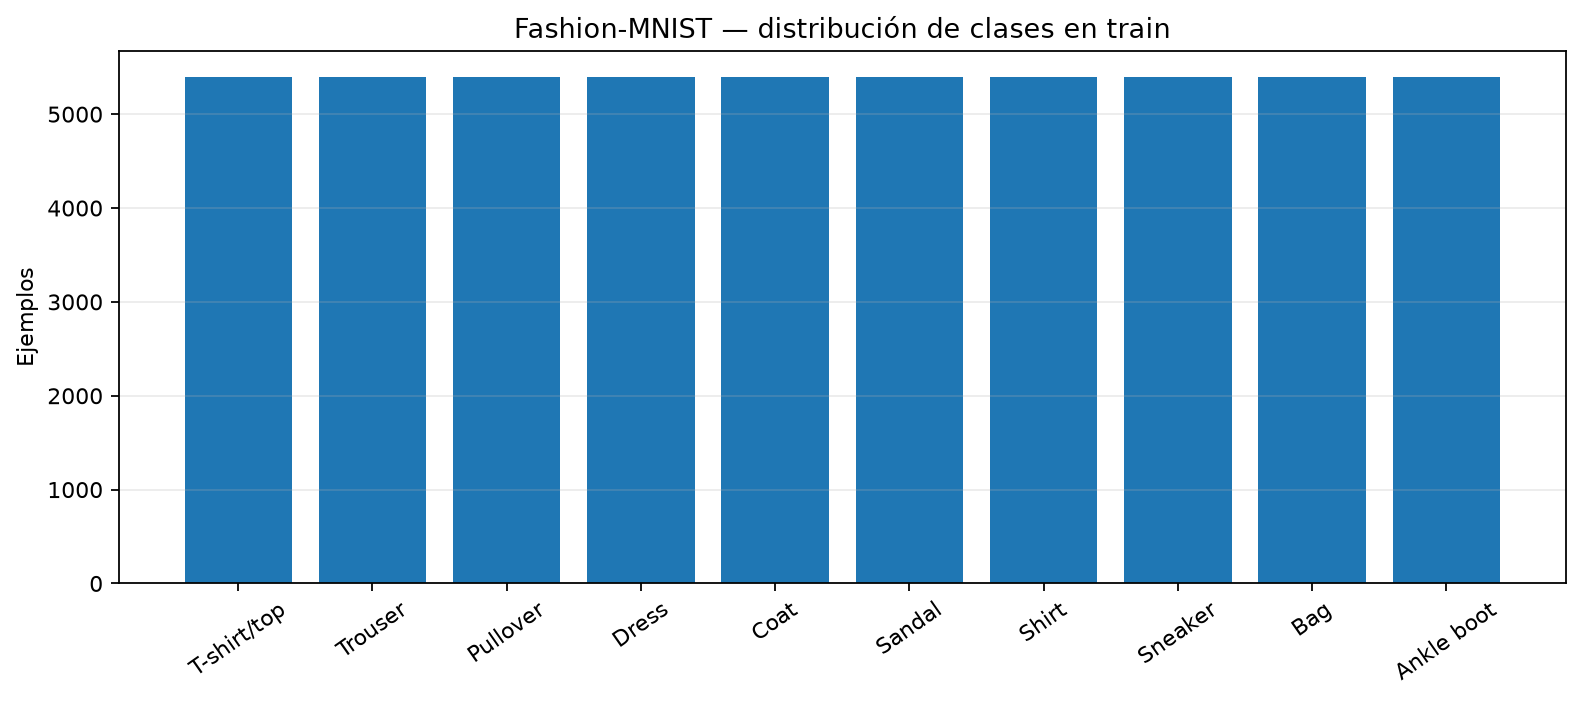

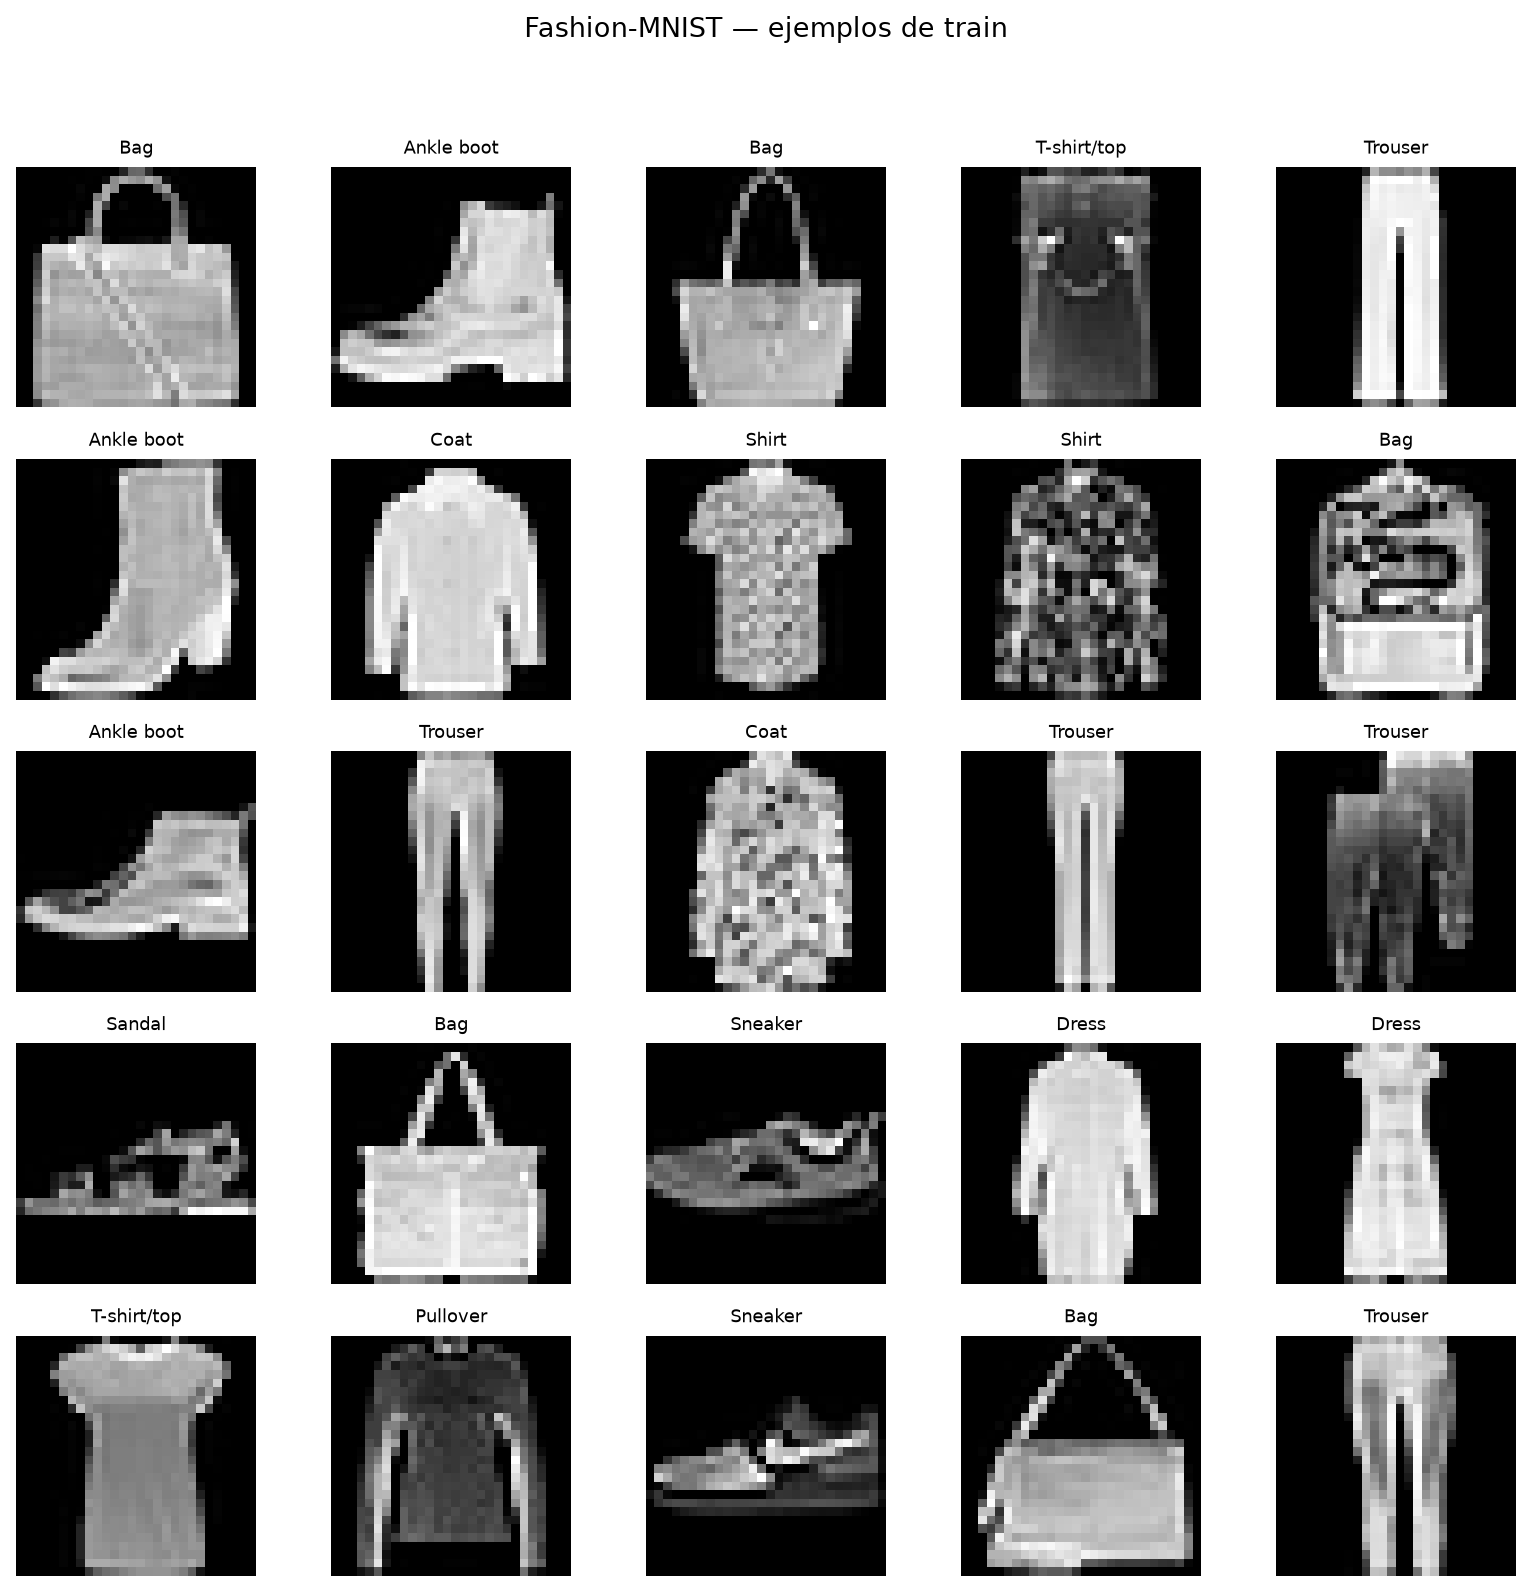

# E0 — resumen de validation

**Configuración:** `configs/baseline.json` · **Seed:** 42 · **Partición:** train 54.000 / validation 6.000.  
**Importante:** el conjunto de test oficial no fue evaluado en esta ejecución.

| Medida | Resultado |
|---|---:|
| Parámetros entrenables | 235.146 |
| Accuracy de validation | 0,8722 |
| Precision macro | 0,8737 |
| Recall macro | 0,8722 |
| F1 macro | 0,8726 |
| Precision ponderada | 0,8737 |
| Recall ponderado | 0,8722 |
| F1 ponderado | 0,8726 |
| Loss de train (época 20) | 0,3751 |
| Loss de validation (época 20) | 0,3666 |

La pérdida de validation disminuyó de 0,7395 a 0,3666 y la accuracy de validation aumentó de 0,7592 a 0,8722 durante las 20 épocas. Como validation contiene 600 ejemplos por clase, las métricas macro y ponderadas coinciden en esta corrida. E0 es un control inicial; no es la configuración final ni habilita evaluación sobre test.


# E1/E2 — comparación controlada en validation

Todos los experimentos usan la misma partición estratificada, seed 42, arquitectura `[256, 128]`, SGD (`learning_rate=0,01`), batch 128 y 20 épocas. El conjunto de test oficial no fue evaluado.

| ID | Única variable modificada | Accuracy validation | F1 macro | F1 ponderado |
|---|---|---:|---:|---:|
| E0 | ReLU + categorical crossentropy | **0,8722** | **0,8726** | **0,8726** |
| E1_tanh | Activación Tanh | 0,8643 | 0,8647 | 0,8647 |
| E1_sigmoid | Activación Sigmoid | 0,7535 | 0,7490 | 0,7490 |
| E2_mse | Loss MSE | 0,7370 | 0,7168 | 0,7168 |

## Lectura posterior

ReLU superó a Tanh por 0,78 puntos porcentuales y a Sigmoid por 11,87 puntos en accuracy de validation. Con ReLU fija, categorical crossentropy superó a MSE por 13,52 puntos. Las métricas macro y ponderadas coinciden porque validation está estratificada y balanceada; ambas se calculan y guardan en el JSON de cada corrida. Estas ejecuciones respaldan conservar ReLU y categorical crossentropy como control para los experimentos siguientes; no sustituyen las comparaciones de hiperparámetros, optimización y regularización.


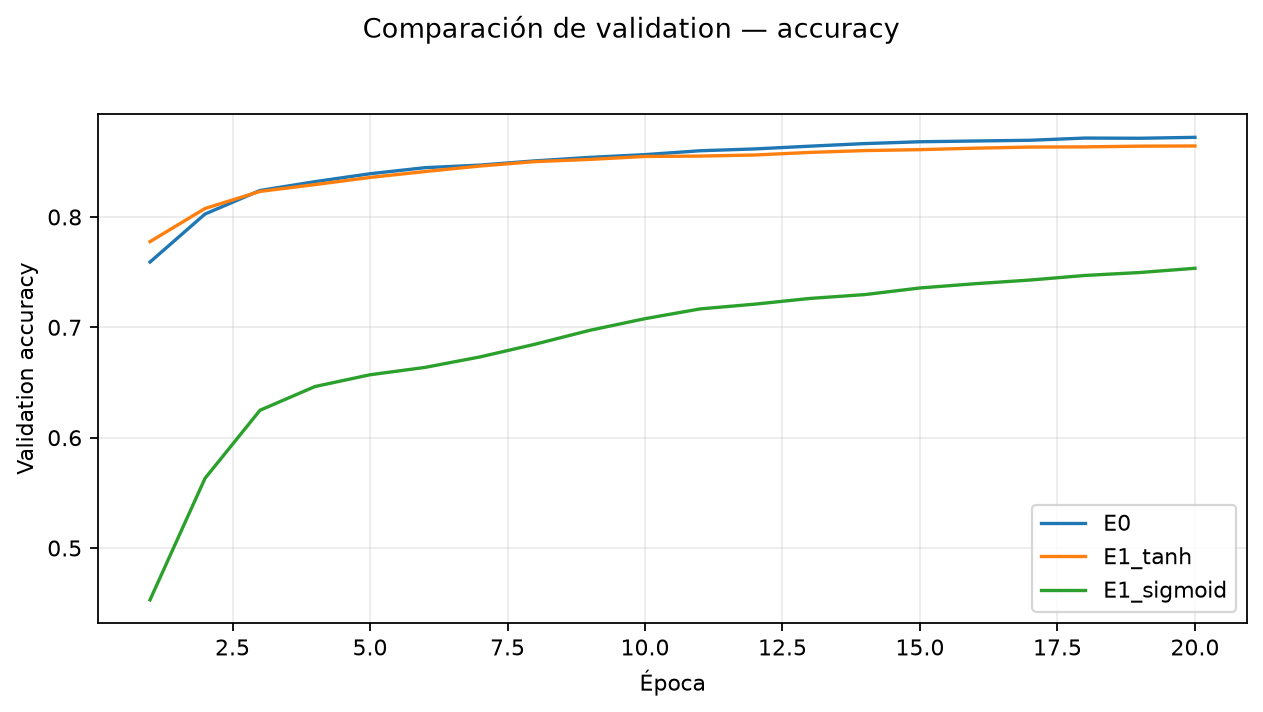

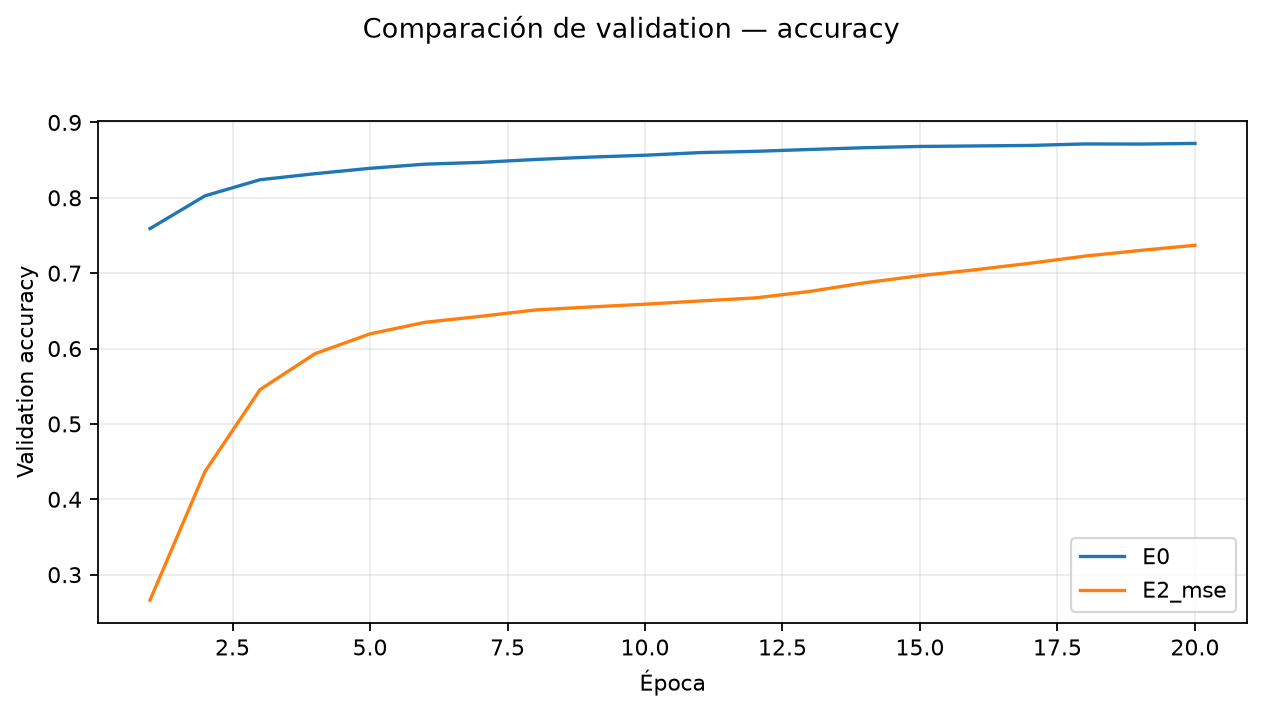

# E3–E5 — métricas completas de validation

Esta tabla conserva la evidencia versionada de Accuracy, Precision, Recall y F1 para los nueve experimentos de Lucas. Todas las métricas se calcularon exclusivamente sobre validation; el test oficial no fue evaluado.

| ID | Accuracy | Precision Macro | Recall Macro | F1 Macro | Precision ponderada | Recall ponderado | F1 ponderado |
|---|---:|---:|---:|---:|---:|---:|---:|
| E3_lr_0_001 | 0,8053 | 0,8042 | 0,8053 | 0,8034 | 0,8042 | 0,8053 | 0,8034 |
| E3_lr_0_01 | 0,8722 | 0,8737 | 0,8722 | 0,8726 | 0,8737 | 0,8722 | 0,8726 |
| E3_lr_0_1 | 0,8933 | 0,8949 | 0,8933 | 0,8936 | 0,8949 | 0,8933 | 0,8936 |
| E4_batch_32 | 0,8860 | 0,8883 | 0,8860 | 0,8864 | 0,8883 | 0,8860 | 0,8864 |
| E4_batch_128 | 0,8933 | 0,8949 | 0,8933 | 0,8936 | 0,8949 | 0,8933 | 0,8936 |
| E4_batch_512 | 0,8745 | 0,8871 | 0,8745 | 0,8771 | 0,8871 | 0,8745 | 0,8771 |
| E5_capacity_64 | 0,8873 | 0,8901 | 0,8873 | 0,8881 | 0,8901 | 0,8873 | 0,8881 |
| E5_capacity_256_128 | **0,8933** | **0,8949** | **0,8933** | **0,8936** | **0,8949** | **0,8933** | **0,8936** |
| E5_capacity_512_256_128 | 0,8990 | 0,8996 | 0,8990 | 0,8989 | 0,8996 | 0,8990 | 0,8989 |

## Interpretación

El split de validation es estratificado y contiene 600 ejemplos de cada clase. Por ese balance exacto, las métricas macro y ponderadas coinciden en estas corridas; se conservan ambas para mantener explícito el contrato y permitir comparaciones futuras si cambia la distribución. Precision Macro ligeramente superior a Recall Macro indica que el promedio de precisión por clase es algo mayor que el promedio de sensibilidad, pero la selección sigue considerando conjuntamente métricas, convergencia, gaps, parámetros y costo.

Los registros completos son regenerables mediante las configuraciones E3–E5 y `run_validation_experiment`; sus salidas locales permanecen bajo `results/runs/` y fuera de Git.


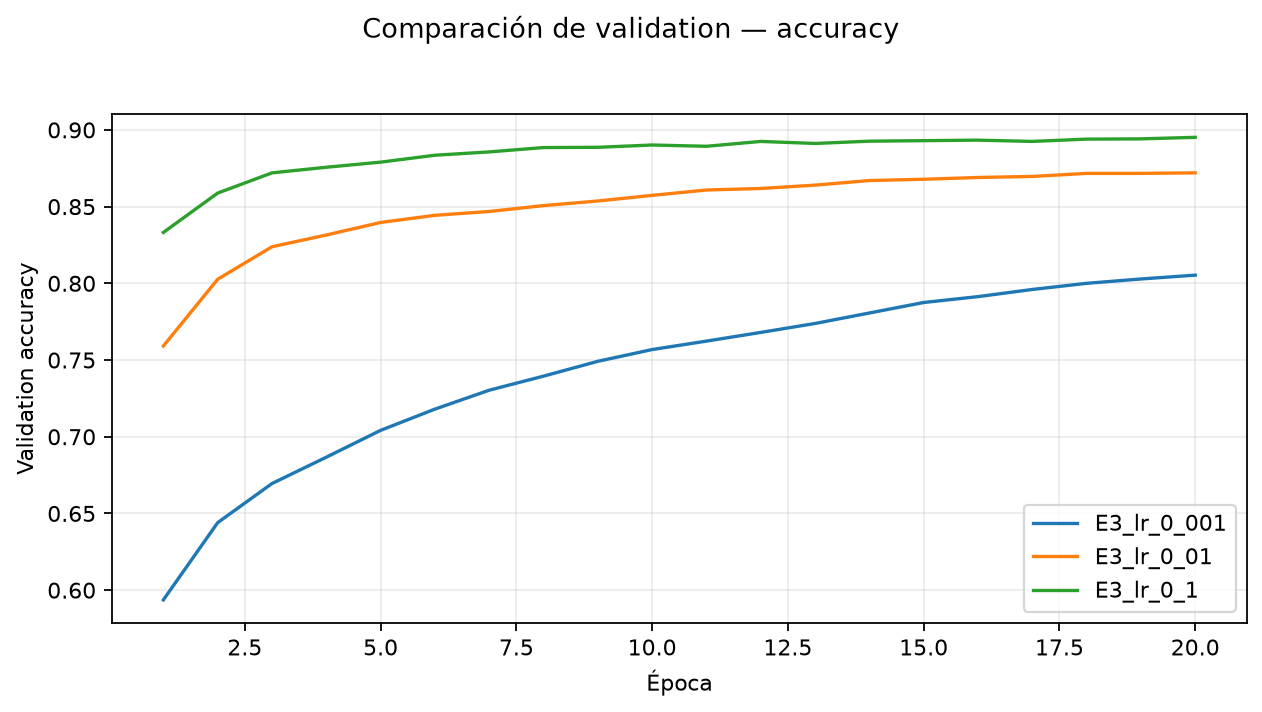

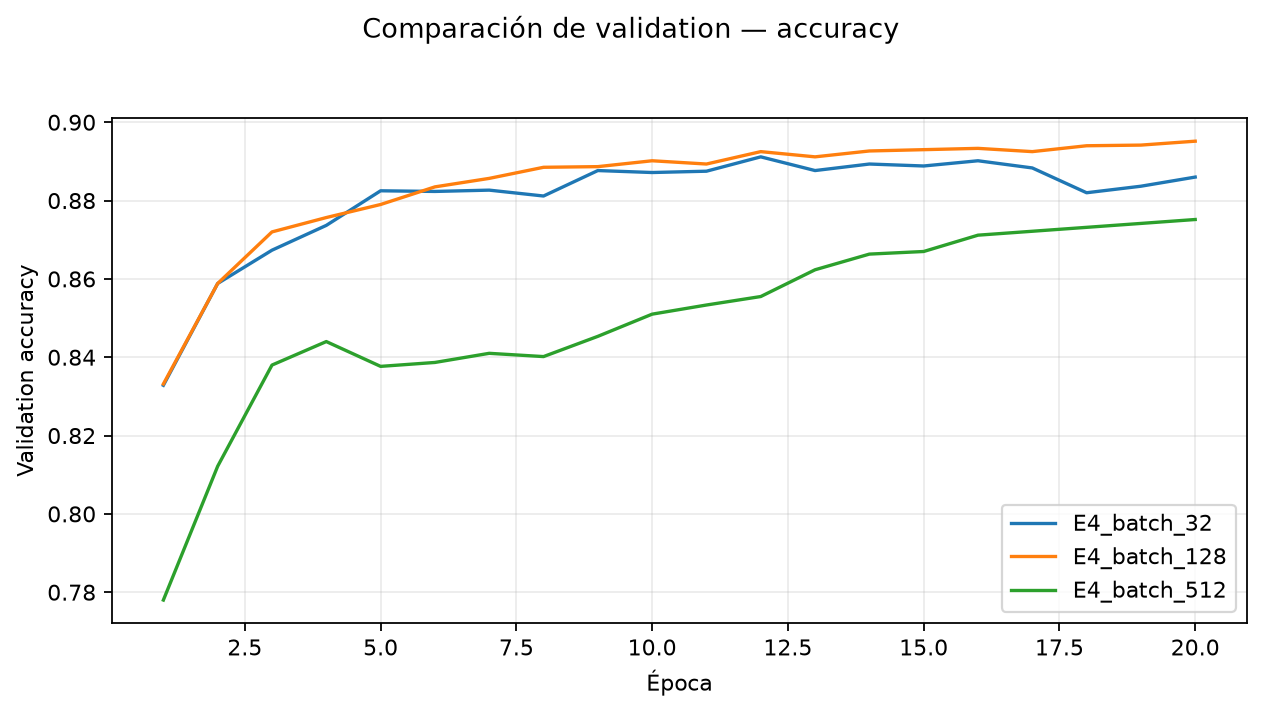

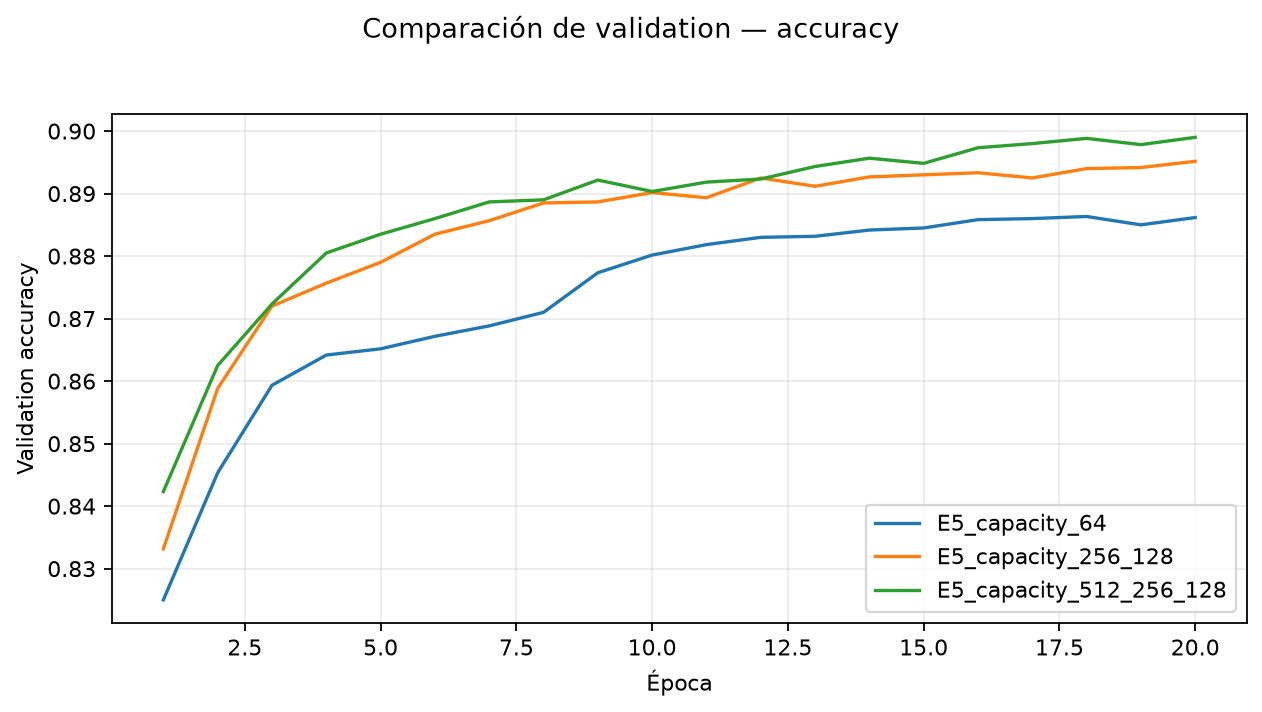

In [9]:
figure('D0_train_class_distribution.png')
figure('D0_train_examples.png')
table('E0_validation_summary.md')
table('E1_E2_validation_comparison.md')
figure('E1_activation_validation_accuracy.png')
figure('E2_loss_validation_accuracy.png')
table('E3_E5_validation_metrics.md')
figure('E3_learning_rate_validation_accuracy.png')
figure('E4_batch_size_validation_accuracy.png')
figure('E5_capacity_validation_accuracy.png')

## 7. Evidencia oficial: optimización y regularización

E6 y E6b comparan optimizadores; E7, E8 y E9 aíslan Dropout, Batch Normalization y L2. Las conclusiones son contextuales: Dropout 0,2 se seleccionó, mientras Batch Normalization y L2 no mejoraron bajo este control.

# E6b — retuning separado de learning rate por optimizador

E6 mostró que Adam y RMSProp quedaron limitados con el learning rate común `0,1`. E6b mantiene fijo cada optimizador y cambia únicamente su learning rate a `0,001`; arquitectura `[256, 128]`, ReLU, Softmax, categorical crossentropy, batch 128, 20 épocas, seed 42 y ausencia de regularización permanecen constantes. El test oficial no fue evaluado ni se generaron predicciones sobre él.

| ID | Optimizador | Learning rate | Accuracy validation | F1 Macro | Mejor val. accuracy (época) | Mejor val. loss (época) | Gap final accuracy | Gap final loss |
|---|---|---:|---:|---:|---:|---:|---:|---:|
| E6_optimizer_sgd | **SGD** | 0,1 | **0,8952** | **0,8954** | **0,8952 (20)** | **0,2975 (20)** | **0,0287** | **0,0851** |
| E6b_adam_lr_0_001 | Adam | 0,001 | 0,8912 | 0,8916 | 0,8912 (17) | 0,3043 (12) | 0,0527 | 0,1941 |
| E6b_rmsprop_lr_0_001 | RMSProp | 0,001 | 0,8933 | 0,8929 | 0,8933 (16) | 0,3137 (8) | 0,0476 | 0,2165 |

`Gap final accuracy = train_accuracy - validation_accuracy`; `gap final loss = validation_loss - train_loss`.

## Decisión provisional

Se mantiene SGD con `learning_rate=0,1` como control provisional para E7. RMSProp recuperó una accuracy cercana, pero quedó 0,18 puntos porcentuales por debajo de SGD, con F1 Macro menor, mayor validation loss y gaps finales de accuracy/loss más altos. Adam también recuperó el aprendizaje, pero quedó por debajo de ambos controles y presentó los gaps más altos.

La diferencia entre SGD y RMSProp es pequeña en accuracy; antes del congelamiento F0 deben repetirse las candidatas relevantes con seeds adicionales si esa diferencia sigue siendo importante para la elección final. Esta decisión solo selecciona un control de continuación para regularización; no congela el modelo ni consulta test.

## Evidencia

- `configs/E6b_adam_lr_0_001.json`
- `configs/E6b_rmsprop_lr_0_001.json`
- `results/figures/E6b_retuned_optimizer_validation_accuracy.png`
- `results/figures/E6b_retuned_optimizer_validation_loss.png`
- Registros regenerables locales bajo `results/runs/E6b_*`.


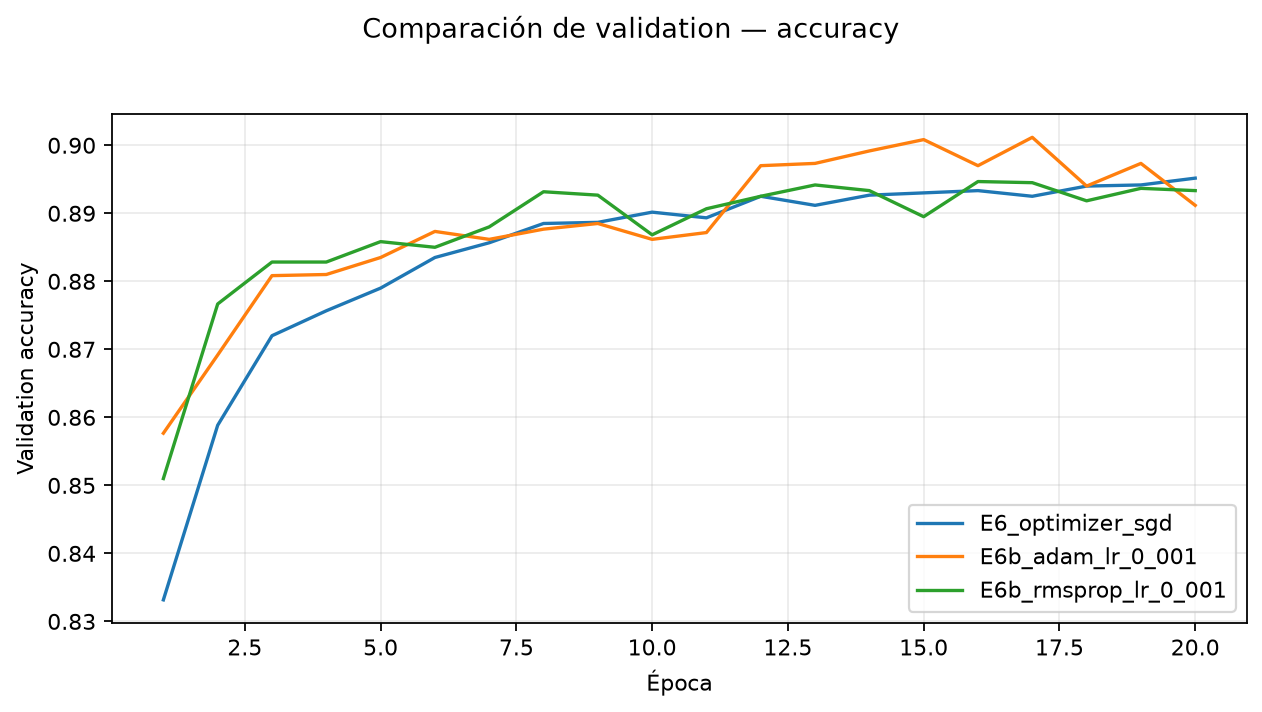

# E7 — comparación controlada de Dropout

Se parte del control provisional SGD con `learning_rate=0,1`, arquitectura `[256, 128]`, ReLU, Softmax, categorical crossentropy, batch 128, 20 épocas y seed 42. La única variable modificada es Dropout: se aplica después de cada capa oculta cuando está activo. Batch Normalization y L2 permanecen desactivados. El conjunto oficial de test no fue evaluado ni se generaron predicciones sobre él.

| ID | Dropout | Accuracy validation | F1 Macro | Mejor val. accuracy (época) | Mejor val. loss (época) | Gap final accuracy | Gap final loss | Duración CPU |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| E7_dropout_0 | 0,0 | 0,8952 | 0,8954 | 0,8952 (20) | 0,2975 (20) | 0,0287 | 0,0851 | **28,83 s** |
| E7_dropout_0_2 | **0,2** | **0,8997** | **0,8997** | **0,8997 (20)** | **0,2830 (20)** | **0,0021** | **0,0135** | 33,09 s |

`Gap final accuracy = train_accuracy - validation_accuracy`; `gap final loss = validation_loss - train_loss`. Las duraciones corresponden a una corrida CPU local y no son comparables con GPU o Colab.

## Decisión

Se selecciona Dropout `0,2` como control para E8. Mejoró 0,45 puntos porcentuales de accuracy y 0,43 puntos de F1 Macro, mientras redujo el gap final de accuracy de 0,0287 a 0,0021 y el gap de loss de 0,0851 a 0,0135. El costo adicional fue de aproximadamente 4,26 segundos en la corrida de referencia.

Esta selección no evalúa combinaciones con Batch Normalization ni L2: E8 y E9 deberán aislar esas técnicas sobre este control. No se congela todavía el modelo ni se consulta test.

## Evidencia

- `configs/E7_dropout_0.json`
- `configs/E7_dropout_0_2.json`
- `results/figures/E7_dropout_validation_accuracy.png`
- `results/figures/E7_dropout_validation_loss.png`
- Registros regenerables locales bajo `results/runs/E7_dropout_*`.


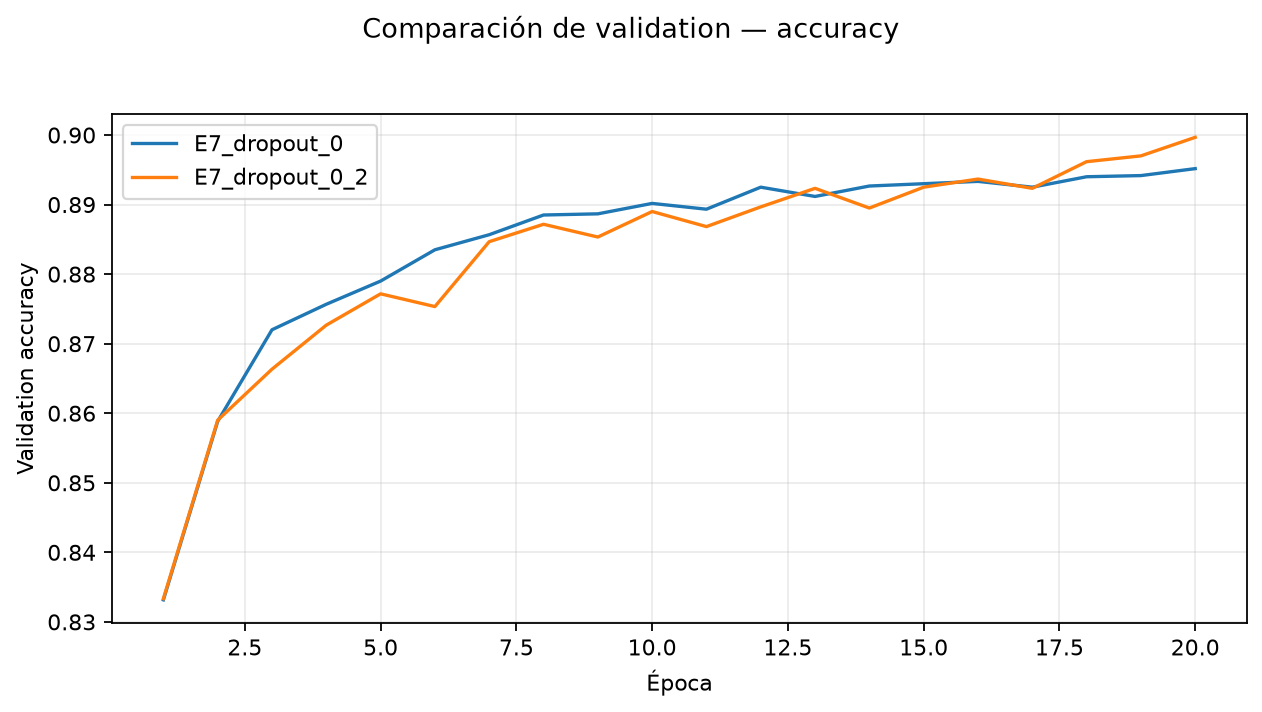

# E8 — comparación controlada de Batch Normalization

Se parte del control seleccionado en E7: MLP `[256, 128]`, ReLU, Softmax, categorical crossentropy, SGD con `learning_rate=0,1`, batch 128, 20 épocas, seed 42, Dropout `0,2` y L2 `0`. La única variable modificada es Batch Normalization. Cuando está activa, cada bloque oculto usa el orden `Dense lineal → BatchNormalization → ReLU → Dropout`. El conjunto oficial de test no fue evaluado ni se generaron predicciones sobre él.

| ID | Batch Normalization | Parámetros | Accuracy validation | F1 Macro | Mejor val. accuracy (época) | Mejor val. loss (época) | Gap final accuracy | Gap final loss | Duración CPU |
|---|---|---:|---:|---:|---:|---:|---:|---:|---:|
| E8_batch_norm_off | OFF | **235.146** | **0,8997** | **0,8997** | **0,8997 (20)** | **0,2830 (20)** | **0,0021** | **0,0135** | **32,79 s** |
| E8_batch_norm_on | ON | 236.682 | 0,8922 | 0,8911 | 0,8922 (19) | 0,3062 (19) | 0,0294 | 0,0827 | 44,20 s |

`Gap final accuracy = train_accuracy - validation_accuracy`; `gap final loss = validation_loss - train_loss`. Las duraciones corresponden a una corrida CPU local y no son comparables con GPU o Colab.

## Decisión

Se mantiene Batch Normalization desactivada para E9. Activarla redujo 0,75 puntos porcentuales de accuracy y 0,86 puntos de F1 Macro, incrementó ambos gaps y añadió 1.536 parámetros y aproximadamente 11,41 segundos a la corrida de referencia.

El resultado no sostiene que Batch Normalization sea inútil en general: solo indica que, con esta arquitectura, Dropout `0,2`, learning rate `0,1` y 20 épocas, no mejoró el control. E9 evaluará L2 de forma separada manteniendo Batch Normalization apagada.

## Evidencia

- `configs/E8_batch_norm_off.json`
- `configs/E8_batch_norm_on.json`
- `results/figures/E8_batch_norm_validation_accuracy.png`
- `results/figures/E8_batch_norm_validation_loss.png`
- Registros regenerables locales bajo `results/runs/E8_batch_norm_*`.


# E9 — comparación controlada de regularización L2

Se parte del control de E8: MLP `[256, 128]`, ReLU, Softmax, categorical crossentropy, SGD con `learning_rate=0,1`, batch 128, 20 épocas, seed 42, Dropout `0,2` y Batch Normalization apagada. La única variable modificada es la fuerza L2. El conjunto oficial de test no fue evaluado ni se generaron predicciones sobre él.

| ID | L2 | Accuracy validation | F1 Macro | Mejor val. accuracy (época) | Mejor val. loss (época) | Gap final accuracy | Gap final loss |
|---|---:|---:|---:|---:|---:|---:|---:|
| E9_l2_0 | **0** | **0,8997** | **0,8997** | **0,8997 (20)** | **0,2804 (20)** | **0,0021** | 0,0135 |
| E9_l2_1e-4 | 0,0001 | 0,8967 | 0,8970 | 0,8985 (19) | 0,3369 (19) | 0,0025 | **0,0102** |

`Gap final accuracy = train_accuracy - validation_accuracy`; `gap final loss = validation_loss - train_loss`. La loss de la fila con L2 incluye la penalización regularizadora; por tanto, no es directamente equivalente a la loss sin L2 como estimación de ajuste puro.

## Decisión

Se mantiene L2 en cero. La variante `1e-4` no superó la Accuracy ni F1 Macro del control y su mejor accuracy (`0,8985`) permaneció por debajo de la accuracy final sin L2 (`0,8997`). Aunque su gap de loss final fue ligeramente menor, el control ya presenta gaps de generalización muy bajos gracias a Dropout `0,2`, por lo que no se justifica introducir complejidad adicional.

Esta decisión es contextual: no afirma que L2 sea inefectiva en general. No se evaluaron combinaciones de L2 con Batch Normalization porque E8 ya mostró que esa técnica no mejoró el control. El modelo no queda congelado ni se consulta test.

## Evidencia

- `configs/E9_l2_0.json`
- `configs/E9_l2_1e-4.json`
- `results/figures/E9_l2_validation_accuracy.png`
- `results/figures/E9_l2_validation_loss.png`
- Registros regenerables locales bajo `results/runs/E9_l2_*`.


# R03 - reproducción canónica de validation

Estas corridas se ejecutaron el 20 de septiembre de 2026 con `src/ep1_fashion_mnist/`, Python 3.12.13 y TensorFlow 2.21.0. No se consultó test. Se realizan para contrastar la auditoría R03, no para retunear ni reemplazar F0.

| Configuración | Accuracy validation | F1 Macro | Lectura |
|---|---:|---:|---|
| SGD, LR 0,1, seed 42 | 0,8952 | 0,8954 | Coincide con la evidencia E6 publicada. |
| Adam, LR 0,001, seed 42 | 0,8912 | 0,8916 | Queda bajo SGD en la métrica final. |
| Sin L2, seed 7 | 0,8902 | 0,8905 | Coincide con la repetición publicada. |
| L2 `1e-4`, seed 7 | 0,8863 | 0,8870 | Coincide con la repetición publicada. |

Una revisión en otro entorno informó un empate prácticamente completo e inversión marginal de la dirección en seed 7. Por eso esta tabla confirma la consistencia del pipeline canónico local, pero no convierte L2 en una conclusión robusta entre entornos.


In [10]:
table('E6b_retuned_optimizer_comparison.md')
figure('E6b_retuned_optimizer_validation_accuracy.png')
table('E7_dropout_comparison.md')
figure('E7_dropout_validation_accuracy.png')
table('E8_batch_norm_comparison.md')
table('E9_l2_comparison.md')
table('R03_canonical_validation_reproduction.md')

## 8. Selección congelada y evaluación final

F0 se seleccionó únicamente con validation. F1 se muestra como evidencia histórica con Accuracy 0,8838 y F1 Macro 0,8836. La matriz de confusión y los errores permiten explicar la limitación principal: Shirt se confunde con prendas superiores visualmente similares.

# Selección final consolidada

## Configuración congelada antes de test

La selección se realizó exclusivamente con train/validation y quedó congelada en `configs/F0_frozen_config.json` antes de consultar el conjunto oficial de test.

| Componente | Selección | Evidencia de validation |
|---|---|---|
| Arquitectura | MLP `[256, 128]` | Equilibrio entre desempeño, parámetros y gaps en E5. |
| Activación / salida / pérdida | ReLU / Softmax / categorical crossentropy | E1/E2; combinación de control para clasificación multiclase. |
| Optimizador | SGD, learning rate `0,1` | E6b: Accuracy `0,8952`, F1 Macro `0,8954`; mejor compromiso frente a Adam y RMSProp retuneados. |
| Batch size / épocas | `128` / `20` | E4 y curvas E7/E9: la mejor validation accuracy y loss quedan al final de las 20 épocas. |
| Dropout | `0,2` | E7: Accuracy `0,8997`, F1 Macro `0,8997` y gaps menores que sin Dropout. |
| Batch Normalization | desactivada | E8: activarla redujo Accuracy y F1 Macro, y aumentó gaps. |
| L2 | `0` | En la ejecución canónica E9 y seed 7, `1e-4` no mejoró Accuracy ni F1 Macro; ante variación externa marginal, se mantiene la opción prudente. |
| Early Stopping | desactivado | No había deterioro ni ahorro material; no se implementó sin una comparación interpretable. |

En el entorno canónico, las dos corridas disponibles favorecieron L2 `0`: Accuracy de validation `0,8997` y `0,8902` (promedio `0,8949`), frente a `0,8967` y `0,8863` con L2 `1e-4` (promedio `0,8915`). Una revisión externa observó una diferencia marginal e inversión en otra ejecución; por ello no se afirma estabilidad robusta entre entornos. L2 `0` se conserva como decisión prudente y trazable, no como superioridad universal.

## Evaluación final única

Después de F0, el modelo seleccionado se entrenó con el split 54.000/6.000 y se evaluó una única vez sobre los 10.000 ejemplos oficiales de test. No se ajustó ningún parámetro después de este resultado.

| Métrica | Test |
|---|---:|
| Accuracy | 0,8838 |
| Precision macro | 0,8844 |
| Recall macro | 0,8838 |
| F1 macro | 0,8836 |
| Precision ponderada | 0,8844 |
| Recall ponderado | 0,8838 |
| F1 ponderado | 0,8836 |

La matriz de confusión muestra dificultades principalmente entre clases de prendas superiores visualmente similares. `Shirt` es la clase con menor F1 (`0,6975`); por ello, este resultado se comunica como limitación del modelo y no se utiliza para hacer nuevos ajustes.

## Trazabilidad

- Decisiones D-014--D-026: `docs/DECISION_LOG.md`.
- Comparaciones: `results/tables/E1_E2_validation_comparison.md`, `E3_learning_rate_comparison.md`, `E4_batch_size_comparison.md`, `E5_capacity_comparison.md`, `E6b_retuned_optimizer_comparison.md`, `E7_dropout_comparison.md`, `E8_batch_norm_comparison.md` y `E9_l2_comparison.md`.
- Protocolo: `results/tables/F0_frozen_protocol.md`.
- Evaluación definitiva: `results/tables/F1_final_test_summary.md` y las figuras `F1_test_*`.


# F0 — configuración y protocolo congelados antes de test

**Estado:** congelado antes de test. El conjunto oficial de test permanece sin evaluación ni predicción.

## Configuración seleccionada

| Componente | Valor congelado |
|---|---|
| Arquitectura | `[256, 128]` |
| Activación oculta / salida | ReLU / Softmax de 10 unidades |
| Loss / etiquetas | categorical crossentropy / one-hot |
| Optimizador / learning rate | SGD / `0,1` |
| Batch / épocas | 128 / 20 |
| Dropout | `0,2` tras cada capa oculta |
| Batch Normalization | desactivada |
| L2 | `0` |
| Early Stopping | desactivado |
| Seed | 42 |

## Criterio y protocolo de selección

La candidata se seleccionó por Accuracy, F1 Macro, curvas de validation, gaps, complejidad y evidencia de E6-E9. E7 eligió Dropout `0,2`; E8 y E9 descartaron Batch Normalization y L2 en las condiciones canónicas evaluadas. Las corridas locales con seed 42 y 7 favorecieron L2 `0`, pero una revisión externa mostró una diferencia marginal e inversión; por ello L2 `0` se congela como opción prudente bajo incertidumbre, sin afirmar estabilidad robusta entre entornos.

Se adopta la estrategia **evaluar el modelo seleccionado que conserva el split 54.000/6.000**. No se reentrenará con los 60.000 ejemplos oficiales: el modelo final se entrenará una vez con la configuración congelada y se evaluará sobre los 10.000 ejemplos de test exactamente una vez. Las 20 épocas se fijan antes de test porque la mejor validation loss/accuracy del control aparece al final del presupuesto y no existe evidencia material para Early Stopping.

## Presupuesto de test

1. Entrenar una única vez el modelo congelado con train 54.000 y validation 6.000.
2. Evaluar y predecir sobre test oficial una sola vez.
3. Calcular métricas globales y por clase, matriz de confusión y ejemplos de errores.
4. No realizar ningún ajuste posterior desde test.

La configuración exacta está en `configs/F0_frozen_config.json`.


### Registro F1 congelado

Configuración: configs/F0_frozen_config.json

Hash F0: 6803517d6777b56f3c4d88639aacdb8a4ab3b993f903bb97d91945dc5e55fd1c

| Métrica | Test histórico |
|---|---:|
| accuracy | 0.8838 |
| precision macro | 0.8844 |
| recall macro | 0.8838 |
| f1 macro | 0.8836 |
| precision weighted | 0.8844 |
| recall weighted | 0.8838 |
| f1 weighted | 0.8836 |

# F1 — evaluación final única sobre test

La configuración `F0_frozen_config` se entrenó con train 54.000/validation 6.000 y se evaluó una única vez sobre los 10.000 ejemplos oficiales de test. Después de esta consulta no se realizaron ajustes.

| Métrica | Test |
|---|---:|
| Accuracy | 0,8838 |
| Precision macro | 0,8844 |
| Recall macro | 0,8838 |
| F1 macro | 0,8836 |
| Precision ponderada | 0,8844 |
| Recall ponderado | 0,8838 |
| F1 ponderado | 0,8836 |

## Métricas por clase

| Clase | Precision | Recall | F1 |
|---|---:|---:|---:|
| T-shirt/top | 0,8721 | 0,7980 | 0,8334 |
| Trouser | 0,9898 | 0,9700 | 0,9798 |
| Pullover | 0,7958 | 0,7990 | 0,7974 |
| Dress | 0,8394 | 0,9250 | 0,8801 |
| Coat | 0,8030 | 0,8070 | 0,8050 |
| Sandal | 0,9795 | 0,9550 | 0,9671 |
| Shirt | 0,7021 | 0,6930 | 0,6975 |
| Sneaker | 0,9238 | 0,9700 | 0,9463 |
| Bag | 0,9710 | 0,9720 | 0,9715 |
| Ankle boot | 0,9674 | 0,9490 | 0,9581 |

La principal dificultad es `Shirt`, seguida por las confusiones visualmente plausibles entre T-shirt/top y Shirt, Pullover y Coat. La matriz de confusión lo respalda; no se ajusta el modelo después de observarlo.

## Evidencia

- `results/figures/F1_test_confusion_matrix.png`
- `results/figures/F1_test_low_confidence_errors.png`
- Registro local protegido: `results/runs/F1_final_test/F1_final_test_record.json`.


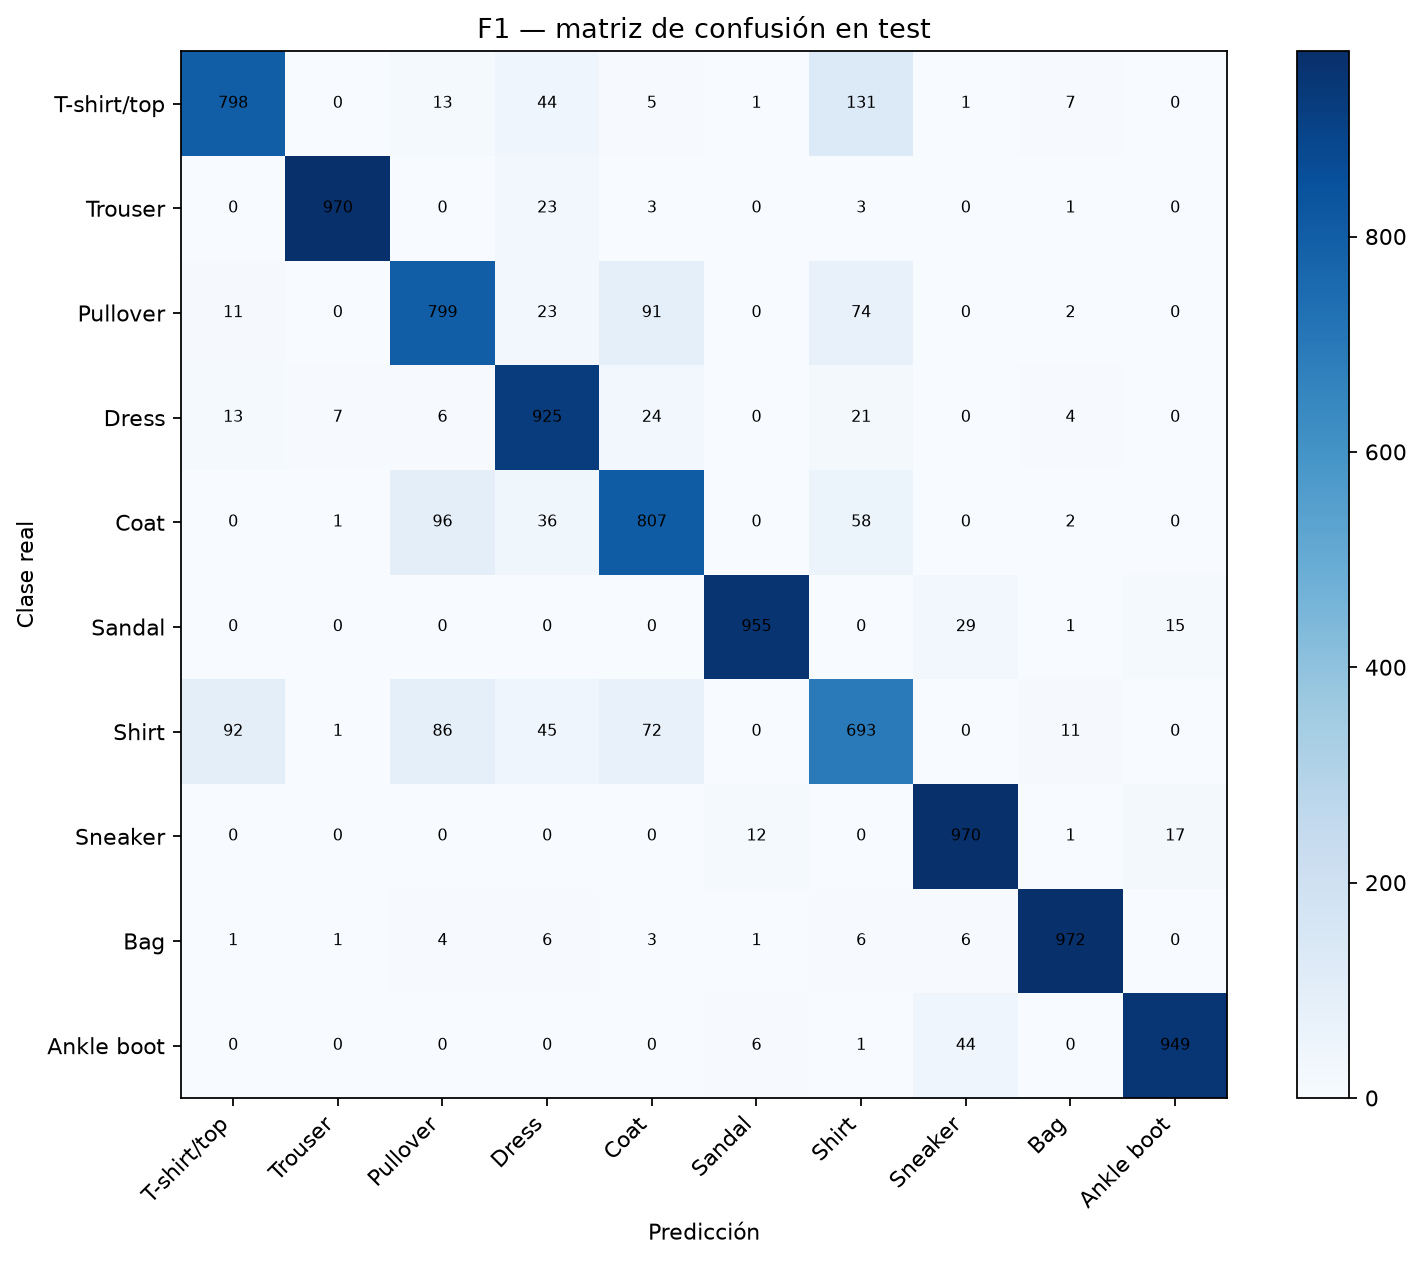

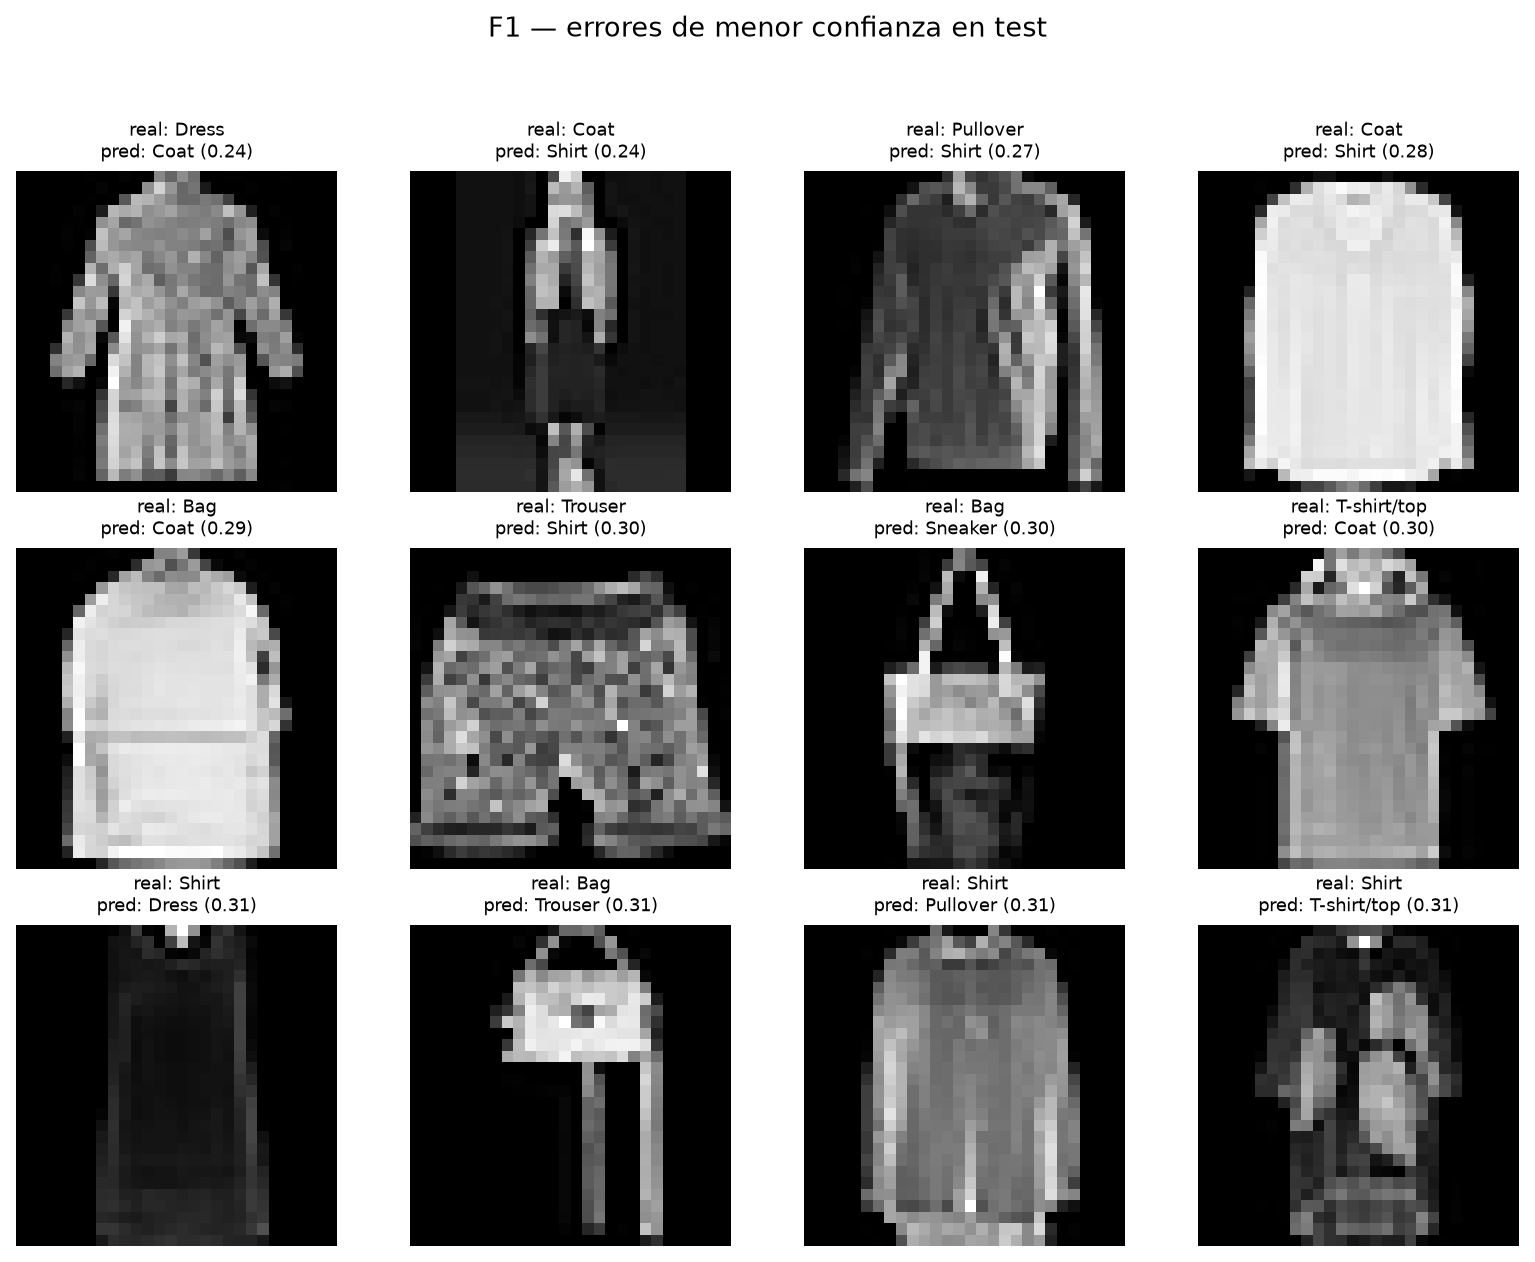

In [11]:
table('FINAL_MODEL_SELECTION.md')
table('F0_frozen_protocol.md')
record = json.loads((RECORDS / 'F1_final_evaluation_record.json').read_text(encoding='utf-8'))
rows = []
for key, value in record['metrics'].items():
    rows.append('| ' + key.replace('_', ' ') + ' | ' + format(value, '.4f') + ' |')
message = '### Registro F1 congelado\n\nConfiguración: ' + record['frozen_config'] + '\n\nHash F0: ' + record['frozen_config_sha256'] + '\n\n| Métrica | Test histórico |\n|---|---:|\n' + '\n'.join(rows)
display(Markdown(message))
table('F1_final_test_summary.md')
figure('F1_test_confusion_matrix.png', width=920)
figure('F1_test_low_confidence_errors.png', width=920)

## Conclusiones para la defensa

- La MLP canónica demuestra el flujo completo: preprocesamiento, construcción, entrenamiento y métricas sobre validation.
- Las decisiones oficiales se basan en comparaciones controladas y en evidencia versionada, no en la demostración rápida.
- La evaluación F1 permanece congelada y no se reutiliza para ajustar el modelo.
- La principal limitación es la confusión de Shirt con T-shirt/top, Pullover y Coat; es una limitación informada, no una razón para modificar el modelo después de test.